## `SARSA_V2 – Agente SARSA con entorno bursátil más realista`

En este cuaderno desarrollamos la segunda versión de nuestro agente SARSA sobre SPY, añadiendo elementos más cercanos a un sistema de trading real: dividimos el histórico en train y test, introducimos valor de cartera con efectivo, costes de transacción, episodios aleatorios de longitud fija y una función de recompensa basada en la rentabilidad diaria de la cartera. Entrenamos el agente en el tramo de entrenamiento, evaluamos su comportamiento en datos nunca vistos y lo comparamos de forma sistemática con la estrategia buy & hold, calculando métricas como Sharpe y drawdown máximo.


C:\Users\34665\AppData\Local\Temp\ipykernel_113180\1274650145.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_spy = yf.download(symbol, start="2010-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Última fecha TRAIN: 2022-02-25 00:00:00
Primera fecha TEST: 2022-02-28 00:00:00
Fechas train: 2010-10-18 → 2022-02-25
Fechas test : 2022-02-28 → 2024-12-31
Episodio   200 | ε = 0.819 | Recompensa media últimas 200: 0.033836
Episodio   400 | ε = 0.670 | Recompensa media últimas 200: 0.054143
Episodio   600 | ε = 0.549 | Recompensa media últimas 200: 0.057631
Episodio   800 | ε = 0.449 | Recompensa media últimas 200: 0.064144
Episodio  1000 | ε = 0.368 | Recompensa media últimas 200: 0.062185
Episodio  1200 | ε = 0.301 | Recompensa media últimas 200: 0.048627
Episodio  1400 | ε = 0.246 | Recompensa media últimas 200: 0.064832
Episodio  1600 | ε = 0.202 | Recompensa media últimas 200: 0.057155
Episodio  1800 | ε = 0.165 | Recompensa media últimas 200: 0.084389
Episodio  2000 | ε = 0.135 | Recompensa media últimas 200: 0.081066
Episodio  2200 | ε = 0.111 | Recompensa media últimas 200: 0.089817
Episodio  2400 | ε = 0.091 | Recompensa media últimas 200: 0.088545
Episodio  2600 | ε = 0.074 |

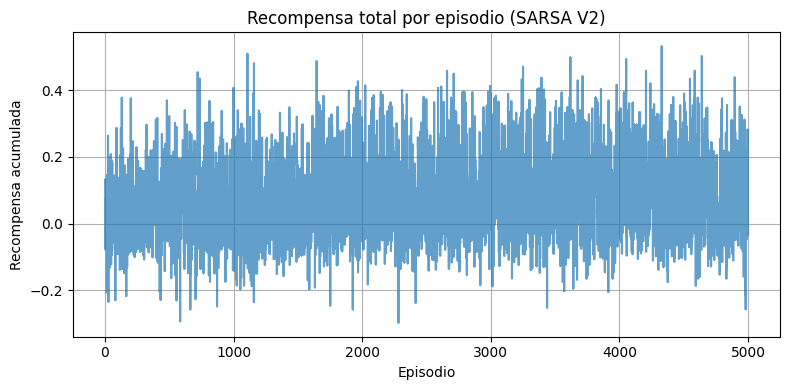

Pasos TRAIN env: 2860 == 2860
Pasos TEST  env: 715 == 715

MÉTRICAS AGENTE SARSA V2 (tuning)
  total_return   :  0.4165
  annual_vol     :  0.1094
  sharpe         :  1.1794
  max_drawdown   : -0.1039

MÉTRICAS BUY & HOLD SPY
  total_return   :  0.4026
  annual_vol     :  0.1732
  sharpe         :  0.7761
  max_drawdown   : -0.2209


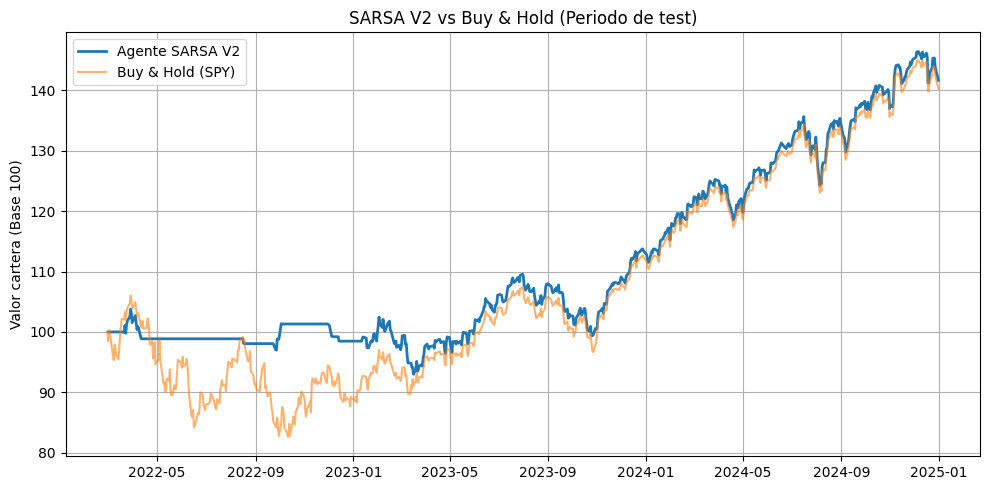

FIN


In [2]:
# =========================================================
# SARSA V2 - Trading con SPY (entorno mejorado + tuning)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random 

import gymnasium as gym
from gymnasium import spaces

import yfinance as yf

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)


# ---------------------------------------------------------
# 1. Descarga de datos de SPY
# ---------------------------------------------------------
symbol = "SPY"

df_spy = yf.download(symbol, start="2010-01-01", end="2025-01-01")
df_spy = df_spy.ffill().dropna()   # por si acaso

# ---------------------------------------------------------
# 2. Ingeniería de variables: SMA200, RSI14, Log_Return
# ---------------------------------------------------------
window_sma = 200
window_rsi = 14

# Usamos solo el cierre
spy = df_spy[["Close"]].copy()          # DataFrame con una sola columna

# SMA 200
spy["SMA200"] = spy["Close"].rolling(window_sma).mean()

# RSI tipo Wilder (14)
delta = spy["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(alpha=1/window_rsi, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/window_rsi, adjust=False).mean()
rs = avg_gain / avg_loss
spy["RSI14"] = 100 - (100 / (1 + rs))

# Log-return diario del activo (lo seguimos guardando, aunque la recompensa será retorno simple)
spy["Log_Return"] = np.log(spy["Close"] / spy["Close"].shift(1))

# Eliminamos NaN iniciales (por medias y retornos)
spy = spy.dropna().copy()

# ---------------------------------------------------------
# 3. Discretización de estados: Tendencia y RSI (robusta)
# ---------------------------------------------------------

# Tendencia: 1 = alcista (precio >= SMA200), 0 = bajista
close_vals = spy["Close"].to_numpy().reshape(-1)
sma_vals   = spy["SMA200"].to_numpy().reshape(-1)
trend_state_vals = (close_vals >= sma_vals).astype(int)
spy["Trend_State"] = pd.Series(trend_state_vals, index=spy.index)

# RSI: 0 = sobreventa, 1 = neutral, 2 = sobrecompra
def rsi_state_fn_scalar(x: float) -> int:
    if x < 30:
        return 0
    elif x > 70:
        return 2
    else:
        return 1

spy["RSI_State"] = spy["RSI14"].apply(rsi_state_fn_scalar)

# ---------------------------------------------------------
# 4. Train / Test split temporal
# ---------------------------------------------------------
split_ratio = 0.8
split_idx = int(len(spy) * split_ratio)

train_data = spy.iloc[:split_idx].copy()
test_data  = spy.iloc[split_idx:].copy()

# --- Comprobación 1: separación temporal correcta ---
last_train_date = train_data.index[-1]
first_test_date = test_data.index[0]

print(f"Última fecha TRAIN: {last_train_date}")
print(f"Primera fecha TEST: {first_test_date}")

assert last_train_date < first_test_date, "¡Data leakage! train y test se solapan en el tiempo."


print(f"Fechas train: {train_data.index[0].date()} → {train_data.index[-1].date()}")
print(f"Fechas test : {test_data.index[0].date()} → {test_data.index[-1].date()}")

# ---------------------------------------------------------
# 5. Entorno Gymnasium mejorado para SARSA
# ---------------------------------------------------------

class SarsaTradingEnvV2(gym.Env):
    """
    Entorno de trading con:
    - 1 activo (SPY)
    - estados discretos (tendencia, RSI, posición)
    - 3 acciones: 0 mantener, 1 comprar, 2 vender
    - recompensa = retorno simple de la cartera (incluyendo costes)
    - episodios en ventanas aleatorias del periodo de datos
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, df: pd.DataFrame,
                 episode_length: int = 252,
                 transaction_cost_rate: float = 0.0005):
        super().__init__()

        self.df = df
        self.prices = df["Close"].values
        self.log_returns = df["Log_Return"].values
        self.trend_states = df["Trend_State"].astype(int).values
        self.rsi_states = df["RSI_State"].astype(int).values
        self.dates = df.index

        self.n_steps = len(df)
        self.episode_length = episode_length
        self.transaction_cost_rate = transaction_cost_rate

        # state = (trend ∈ {0,1}, rsi ∈ {0,1,2}, position ∈ {0,1}) → 12 estados
        self.observation_space = spaces.Discrete(12)

        # actions: 0 = mantener, 1 = comprar, 2 = vender
        self.action_space = spaces.Discrete(3)

        # estado interno
        self.current_step = None
        self.end_step = None
        self.position = None      # 0 cash, 1 largo
        self.portfolio_value = None
        self.initial_value = 100.0

    def _encode_state(self, t: int, position: int) -> int:
        trend = self.trend_states[t]
        rsi   = self.rsi_states[t]
        state_id = trend * 6 + rsi * 2 + position
        return int(state_id)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        # inicio aleatorio del episodio dentro del periodo
        max_start = self.n_steps - self.episode_length - 1
        if max_start <= 0:
            start = 0
            self.end_step = self.n_steps - 1
        else:
            start = self.np_random.integers(0, max_start + 1)
            self.end_step = start + self.episode_length

        self.current_step = start
        self.position = 0       # empezamos en efectivo
        self.portfolio_value = self.initial_value

        state = self._encode_state(self.current_step, self.position)
        info = {
            "portfolio_value": self.portfolio_value,
            "date": self.dates[self.current_step],
        }
        return state, info

    def step(self, action: int):
        assert self.action_space.contains(action)

        prev_value    = self.portfolio_value
        prev_position = self.position

        # 0 = mantener, 1 = comprar, 2 = vender
        if action == 1:
            self.position = 1
        elif action == 2:
            self.position = 0

        transaction_cost = 0.0
        if self.position != prev_position:
            transaction_cost = self.transaction_cost_rate * prev_value

        self.current_step += 1
        done = self.current_step >= self.end_step

        # retorno simple del activo
        log_ret = self.log_returns[self.current_step]
        asset_ret = np.exp(log_ret) - 1.0

        if self.position == 1:
            self.portfolio_value = prev_value * (1.0 + asset_ret)
        else:
            self.portfolio_value = prev_value

        self.portfolio_value -= transaction_cost
        self.portfolio_value = max(self.portfolio_value, 1e-8)

        # *** CAMBIO IMPORTANTE: recompensa = retorno simple de la cartera ***
        reward = (self.portfolio_value / prev_value) - 1.0

        next_state = self._encode_state(self.current_step, self.position)
        info = {
            "portfolio_value": self.portfolio_value,
            "date": self.dates[self.current_step],
            "transaction_cost": transaction_cost,
            "asset_return": asset_ret,
        }

        return next_state, reward, done, False, info

    def render(self):
        print(
            f"{self.dates[self.current_step].date()} | "
            f"pos: {self.position} | "
            f"V: {self.portfolio_value:.2f}"
        )

# ---------------------------------------------------------
# 6. Métricas para la evaluación
# ---------------------------------------------------------

def compute_metrics(equity_curve: pd.Series):
    """
    equity_curve: serie de valor de cartera (base 100)
    """
    if isinstance(equity_curve, pd.DataFrame):
        equity_curve = equity_curve.iloc[:, 0]

    rets = equity_curve.pct_change().dropna()

    total_return = float(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1)

    mean_ret = float(rets.mean())
    std_ret  = float(rets.std())

    if std_ret is None or np.isnan(std_ret) or std_ret == 0.0:
        sharpe = np.nan
    else:
        sharpe = (mean_ret / std_ret) * np.sqrt(252)

    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1
    max_dd = float(drawdown.min())

    return {
        "total_return": total_return,
        "annual_vol": std_ret * np.sqrt(252),
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

# ---------------------------------------------------------
# 7. Entrenamiento SARSA con episodios aleatorios (tuning)
# ---------------------------------------------------------

env = SarsaTradingEnvV2(
    train_data,
    episode_length=252,          # ~1 año
    transaction_cost_rate=0.0005 # 0,05 %
)

n_states  = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

alpha = 0.05        # aprendizaje algo más suave
gamma = 0.99        # miramos más al futuro

n_episodes    = 5000     # más episodios

epsilon_start = 1.0
epsilon_end   = 0.05
epsilon_decay = 0.999    # exploración baja más despacio

def epsilon_greedy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))

episode_rewards = []
epsilon = epsilon_start

for ep in range(n_episodes):
    # usamos una semilla distinta pero determinista por episodio
    state, info = env.reset(seed=SEED + ep)
    action = epsilon_greedy(state, epsilon)
    done = False
    total_reward = 0.0

    while not done:
        next_state, reward, done, _, info = env.step(action)
        total_reward += reward

        if not done:
            next_action = epsilon_greedy(next_state, epsilon)
            td_target = reward + gamma * Q[next_state, next_action]
        else:
            next_action = None
            td_target = reward

        td_error = td_target - Q[state, action]
        Q[state, action] += alpha * td_error

        state = next_state
        action = next_action if next_action is not None else 0

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    if (ep + 1) % 200 == 0:
        mean_last = np.mean(episode_rewards[-200:])
        print(f"Episodio {ep+1:5d} | ε = {epsilon:.3f} | "
              f"Recompensa media últimas 200: {mean_last:.6f}")

# Evolución de la recompensa por episodio
plt.figure(figsize=(8,4))
plt.plot(episode_rewards, alpha=0.7)
plt.title("Recompensa total por episodio (SARSA V2)")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Evaluación en test + gráfico
# ---------------------------------------------------------

test_env = SarsaTradingEnvV2(
    test_data,
    episode_length=len(test_data) - 2,
    transaction_cost_rate=0.0005
)

# --- Comprobación 2: cada entorno solo ve sus datos ---
print("Pasos TRAIN env:", len(env.log_returns), "==", len(train_data))
print("Pasos TEST  env:", len(test_env.log_returns), "==", len(test_data))

assert len(env.log_returns) == len(train_data), "Env de TRAIN no coincide con train_data."
assert len(test_env.log_returns) == len(test_data), "Env de TEST no coincide con test_data."


state, info = test_env.reset(seed=SEED)  # usamos la misma base
test_env.current_step = 0
test_env.end_step = len(test_data) - 1
test_env.position = 0
test_env.portfolio_value = test_env.initial_value

dates = []
values_agent = []

done = False
while not done:
    action = int(np.argmax(Q[state]))   # política greedy
    next_state, reward, done, _, info = test_env.step(action)

    dates.append(info["date"])
    values_agent.append(info["portfolio_value"])

    state = next_state

equity_agent = pd.Series(values_agent, index=dates)

# Curva buy & hold en el mismo periodo
bh_prices = test_data["Close"]
bh_equity = (bh_prices / bh_prices.iloc[0]) * 100

# Métricas
metrics_agent = compute_metrics(equity_agent)
metrics_bh    = compute_metrics(bh_equity)

print("\nMÉTRICAS AGENTE SARSA V2 (tuning)")
for k, v in metrics_agent.items():
    print(f"  {k:15s}: {v: .4f}")

print("\nMÉTRICAS BUY & HOLD SPY")
for k, v in metrics_bh.items():
    print(f"  {k:15s}: {v: .4f}")

plt.figure(figsize=(10, 5))
plt.plot(equity_agent.index, equity_agent.values,
         label="Agente SARSA V2", linewidth=2)
plt.plot(bh_equity.index, bh_equity.values,
         label="Buy & Hold (SPY)", alpha=0.6)
plt.title("SARSA V2 vs Buy & Hold (Periodo de test)")
plt.ylabel("Valor cartera (Base 100)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print("FIN")
